In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries Loaded ✅")

Libraries Loaded ✅


In [25]:
df = pd.read_csv('../data/raw/uber-raw-data-apr14.csv')
df.head()

,Date/Time,Lat,Lon,Base
0,4/1/2014 0:11:00,40.7690,-73.9549,B02512
1,4/1/2014 0:17:00,40.7267,-74.0345,B02512
2,4/1/2014 0:21:00,40.7316,-73.9873,B02512
3,4/1/2014 0:28:00,40.7588,-73.9776,B02512
4,4/1/2014 0:33:00,40.7594,-73.9722,B02512


In [26]:
print("Shape:", df.shape)

df.info()

df.describe()

Shape: (564516, 4)
<class 'pandas.DataFrame'>
RangeIndex: 564516 entries, 0 to 564515
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   Date/Time  564516 non-null  str    
 1   Lat        564516 non-null  float64
 2   Lon        564516 non-null  float64
 3   Base       564516 non-null  str    
dtypes: float64(2), str(2)
memory usage: 17.2 MB


,Lat,Lon
count,564516.000000,564516.000000
mean,40.740005,-73.976817
std,0.036083,0.050426
min,40.072900,-74.773300
25%,40.722500,-73.997700
50%,40.742500,-73.984800
75%,40.760700,-73.970000
max,42.116600,-72.066600


In [27]:
df.isnull().sum()

Date/Time    0
Lat          0
Lon          0
Base         0
dtype: int64

In [28]:
df['Date/Time'] = pd.to_datetime(df['Date/Time'])

In [29]:
df['hour'] = df['Date/Time'].dt.hour
df['day'] = df['Date/Time'].dt.day
df['month'] = df['Date/Time'].dt.month
df['day_of_week'] = df['Date/Time'].dt.dayofweek

In [30]:
df['demand'] = 1

In [31]:
hourly_demand = df.groupby('hour')['demand'].sum()

In [32]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('../data/raw/uber-raw-data-apr14.csv')

df['Date/Time'] = pd.to_datetime(df['Date/Time'])

df['hour'] = df['Date/Time'].dt.hour
df['day'] = df['Date/Time'].dt.day
df['month'] = df['Date/Time'].dt.month
df['day_of_week'] = df['Date/Time'].dt.dayofweek

print("Loaded successfully ✅")

Loaded successfully ✅


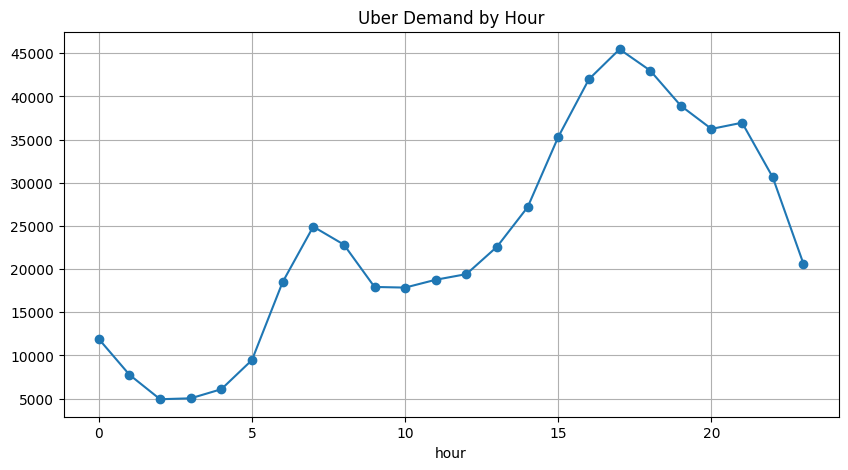

In [33]:
plt.figure(figsize=(10,5))
df.groupby('hour').size().plot(marker='o')
plt.title("Uber Demand by Hour")
plt.grid()
plt.show()

In [34]:
!pip install pandas numpy matplotlib seaborn scikit-learn

Defaulting to user installation because normal site-packages is not writeable


In [35]:
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# 1. LOAD DATA
# =========================
df = pd.read_csv('../data/raw/uber-raw-data-apr14.csv')

print("Loaded successfully ✅")
print("Shape:", df.shape)

# =========================
# 2. CONVERT DATE COLUMN
# =========================
df['Date/Time'] = pd.to_datetime(df['Date/Time'])

# =========================
# 3. FEATURE ENGINEERING
# =========================
df['hour'] = df['Date/Time'].dt.hour
df['day'] = df['Date/Time'].dt.day
df['month'] = df['Date/Time'].dt.month
df['day_of_week'] = df['Date/Time'].dt.dayofweek

# demand column (important for ML later)
df['demand'] = 1

print("Feature engineering done ✅")
df.head()

Loaded successfully ✅
Shape: (564516, 4)
Feature engineering done ✅


,Date/Time,Lat,Lon,Base,hour,day,month,day_of_week,demand
0,2014-04-01 00:11:00,40.7690,-73.9549,B02512,0,1,4,1,1
1,2014-04-01 00:17:00,40.7267,-74.0345,B02512,0,1,4,1,1
2,2014-04-01 00:21:00,40.7316,-73.9873,B02512,0,1,4,1,1
3,2014-04-01 00:28:00,40.7588,-73.9776,B02512,0,1,4,1,1
4,2014-04-01 00:33:00,40.7594,-73.9722,B02512,0,1,4,1,1


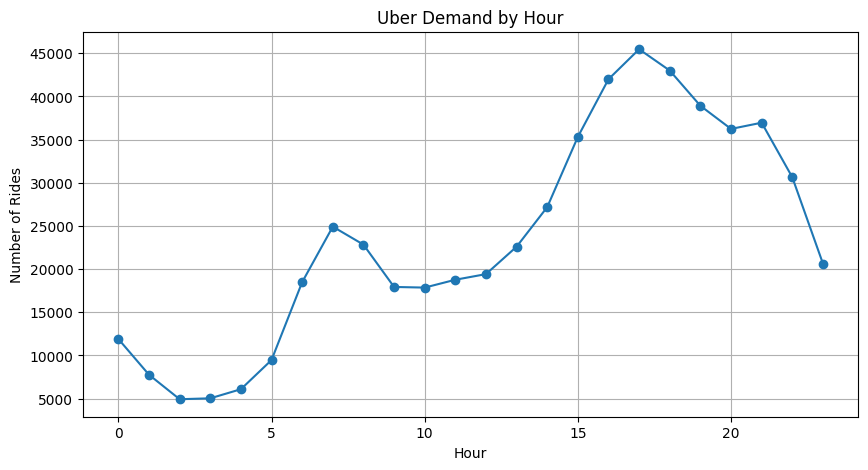

In [36]:
plt.figure(figsize=(10,5))
df.groupby('hour').size().plot(marker='o')
plt.title("Uber Demand by Hour")
plt.xlabel("Hour")
plt.ylabel("Number of Rides")
plt.grid()
plt.show()

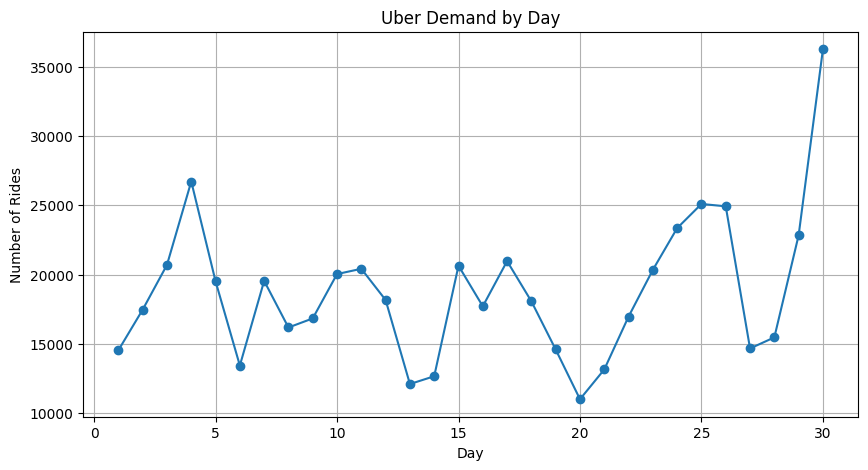

In [37]:
plt.figure(figsize=(10,5))
df.groupby('day').size().plot(marker='o')
plt.title("Uber Demand by Day")
plt.xlabel("Day")
plt.ylabel("Number of Rides")
plt.grid()
plt.show()

In [38]:
# Create hourly demand dataset
hourly_df = df.groupby(['hour', 'day', 'month', 'day_of_week']).size().reset_index(name='demand')

print("Hourly dataset created ✅")
hourly_df.head()

Hourly dataset created ✅


,hour,day,month,day_of_week,demand
0,0,1,4,1,138
1,0,2,4,2,161
2,0,3,4,3,194
3,0,4,4,4,329
4,0,5,4,5,723


In [39]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

# Features and target
X = hourly_df[['hour', 'day', 'month', 'day_of_week']]
y = hourly_df['demand']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Data split done ✅")

Data split done ✅


In [40]:
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

print("Model trained successfully ✅")

Model trained successfully ✅


In [41]:
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)

print("Model Evaluation Done ✅")
print("MAE Error:", mae)

Model Evaluation Done ✅
MAE Error: 77.1075


In [42]:
print("Sample Predictions:")
print(y_pred[:10])

Sample Predictions:
[ 651.98  518.06  242.52  211.55 1447.89  447.27  184.14  271.9   682.59
  632.55]


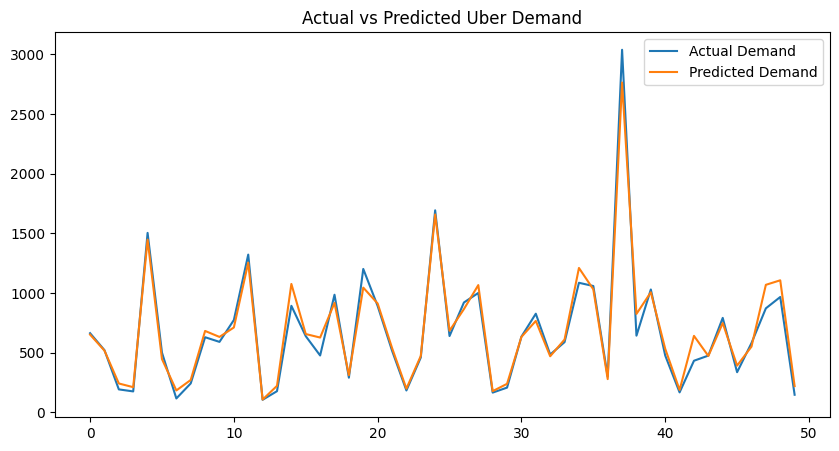

In [43]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(y_test.values[:50], label="Actual Demand")
plt.plot(y_pred[:50], label="Predicted Demand")
plt.title("Actual vs Predicted Uber Demand")
plt.legend()
plt.show()

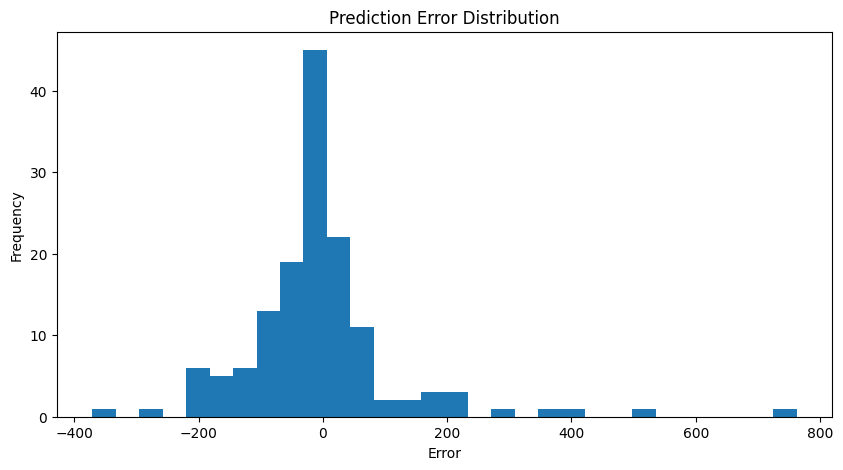

In [44]:
errors = y_test.values - y_pred

plt.figure(figsize=(10,5))
plt.hist(errors, bins=30)
plt.title("Prediction Error Distribution")
plt.xlabel("Error")
plt.ylabel("Frequency")
plt.show()

In [45]:
from sklearn.ensemble import GradientBoostingRegressor

model = GradientBoostingRegressor()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

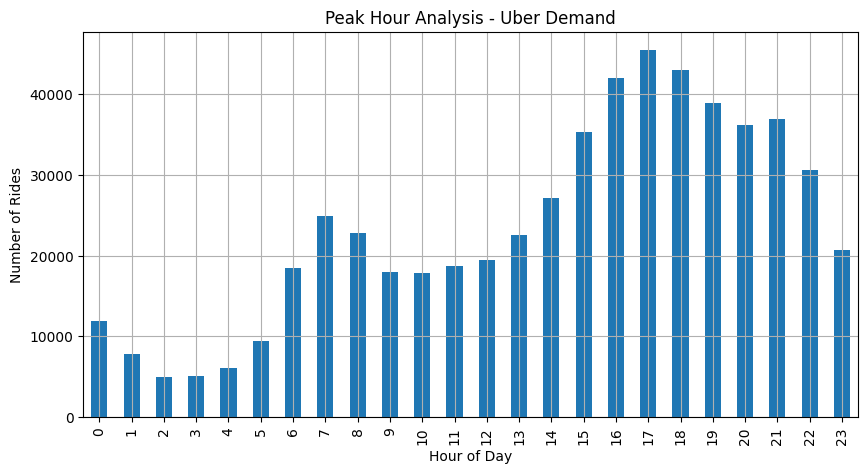

In [46]:
import matplotlib.pyplot as plt

peak_hours = df.groupby('hour').size()

plt.figure(figsize=(10,5))
peak_hours.plot(kind='bar')
plt.title("Peak Hour Analysis - Uber Demand")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Rides")
plt.grid()
plt.show()

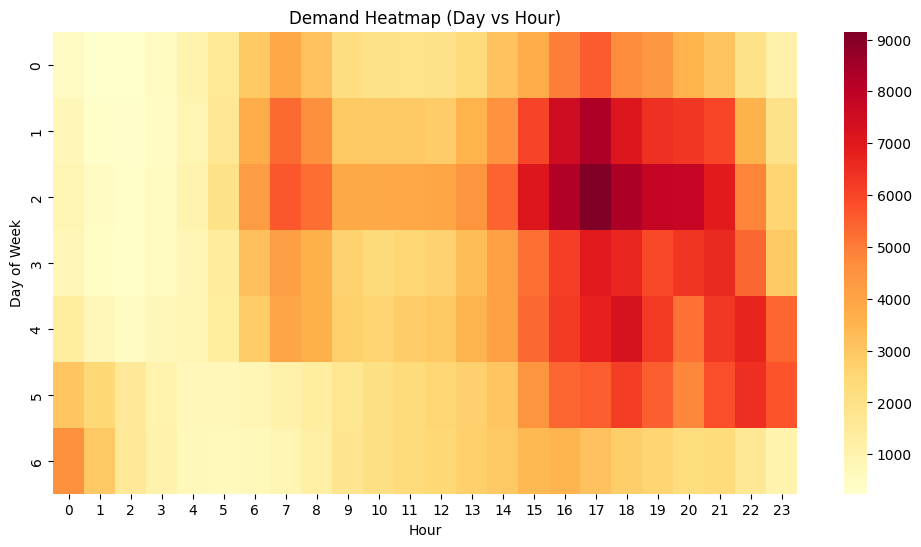

In [47]:
import seaborn as sns

heatmap_data = df.groupby(['day_of_week', 'hour']).size().unstack()

plt.figure(figsize=(12,6))
sns.heatmap(heatmap_data, cmap="YlOrRd")
plt.title("Demand Heatmap (Day vs Hour)")
plt.xlabel("Hour")
plt.ylabel("Day of Week")
plt.show()

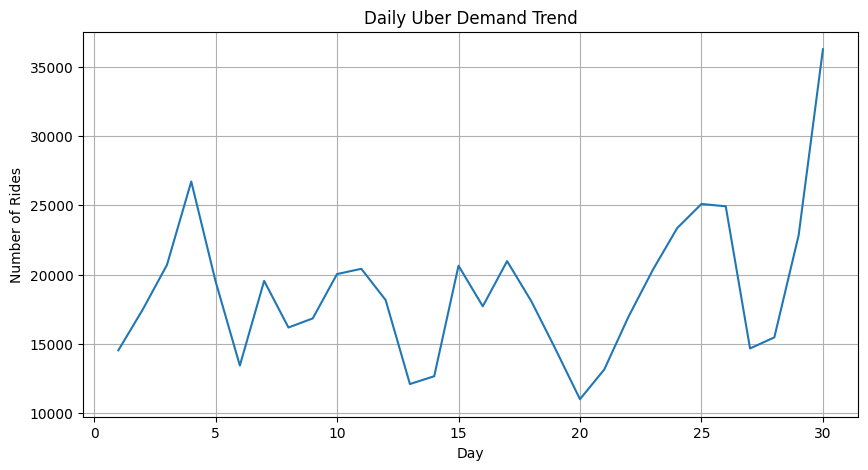

In [48]:
daily_demand = df.groupby('day').size()

plt.figure(figsize=(10,5))
daily_demand.plot()
plt.title("Daily Uber Demand Trend")
plt.xlabel("Day")
plt.ylabel("Number of Rides")
plt.grid()
plt.show()

In [49]:
!pip install streamlit
  

Defaulting to user installation because normal site-packages is not writeable
